In [1]:
cd /g/data/mn51/users/gt3409/plotting_maps/

/g/data/mn51/users/gt3409/plotting_maps


In [2]:
from acs_area_statistics import acs_regional_stats, regions
import xarray as xr
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
filename = "/g/data/ia39/ncra/extratropical_storms/5km/GWLs/lows_AGCD-05i_MM10_ssp370_v1-r1_GWL12.nc"
ds = xr.open_dataset(filename, use_cftime = True,)
var="low_freq"
dims=("lat", "lon",)
mask = regions.mask_3D(ds)


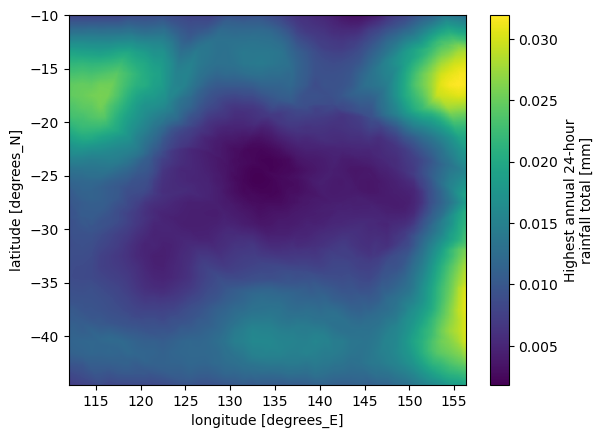

In [4]:
ds[var].plot()

In [5]:
df = acs_regional_stats(ds=ds, var=var,  mask = "centred", how = ["min", "mean", "median", "max",], dims = dims,)
df

!warning slow! Calculating mask every time is slow.         
Please consider calculating ```mask = regions.mask_3D(ds)``` before this function.


<xarray.Dataset> Size: 3kB
Dimensions:          (region: 10)
Coordinates:
  * region           (region) int64 80B 0 1 2 3 4 5 6 7 8 9
    abbrevs          (region) <U8 320B 'WANorth' 'WASouth' ... 'QLDSouth' 'AUS'
    names            (region) <U48 2kB 'Western Australia North' ... 'Australia'
Data variables:
    low_freq_min     (region) float32 40B 0.003668 0.003567 ... 0.0031 0.00184
    low_freq_mean    (region) float64 80B 0.01163 0.00648 ... 0.004975 0.00759
    low_freq_median  (region) float64 80B 0.01217 0.005626 ... 0.004515 0.006645
    low_freq_max     (region) float32 40B 0.02147 0.01441 ... 0.01217 0.02147

In [6]:
filename = "/g/data/ia39/ncra/extratropical_storms/5km/GWLs/RX1H_AGCD-05i_MM90_ssp370_v1-r1_GWL15_change.nc"
ds = xr.open_dataset(filename, use_cftime = True,)
var="prhmax"
dims=("lat", "lon",)
mask = regions.mask_3D(ds)

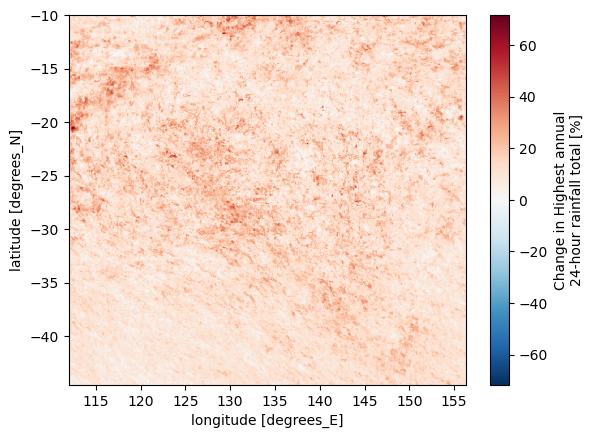

In [7]:
ds[var].plot()

In [8]:
mask_centred = regions.mask_3D(ds)
df = acs_regional_stats(ds=ds, var=var,  mask = mask_centred, how = ["min", "mean", "median", "max",], dims = dims,)
df

<xarray.Dataset> Size: 3kB
Dimensions:        (region: 10)
Coordinates:
  * region         (region) int64 80B 0 1 2 3 4 5 6 7 8 9
    abbrevs        (region) <U8 320B 'WANorth' 'WASouth' ... 'QLDSouth' 'AUS'
    names          (region) <U48 2kB 'Western Australia North' ... 'Australia'
Data variables:
    prhmax_min     (region) float32 40B -3.104 -0.4038 -1.494 ... -1.769 -3.106
    prhmax_mean    (region) float64 80B 14.54 15.02 13.15 ... 11.36 13.91 14.14
    prhmax_median  (region) float64 80B 13.83 14.51 12.58 ... 10.54 13.14 13.47
    prhmax_max     (region) float32 40B 57.72 49.3 42.62 ... 42.05 50.28 57.72

In [9]:
stat ="p90"
int(stat.replace("p", ""))

90

In [10]:
(int(stat.replace("p", "")) <= 100)

True

In [11]:
df = acs_regional_stats(ds=xr.ones_like(ds), var=var,  mask = "fractional", how = ["min", "mean", "median", "max", "sum", "p90"], dims = dims,)
df

!warning very slow! Calculating fractional mask every time is very slow.         
Please consider calculating `mask = regions.mask_3D_frac_approx(ds)` before function.


<xarray.Dataset> Size: 3kB
Dimensions:        (region: 10)
Coordinates:
  * region         (region) int64 80B 0 1 2 3 4 5 6 7 8 9
    abbrevs        (region) <U8 320B 'WANorth' 'WASouth' ... 'QLDSouth' 'AUS'
    names          (region) <U48 2kB 'Western Australia North' ... 'Australia'
Data variables:
    prhmax_min     (region) float32 40B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    prhmax_mean    (region) float64 80B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    prhmax_median  (region) float64 80B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    prhmax_max     (region) float32 40B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    prhmax_sum     (region) float64 80B 3.442e+04 4.747e+04 ... 2.492e+05
    prhmax_p90     (region) float64 80B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0

In [12]:
df = acs_regional_stats(ds=xr.zeros_like(ds), var=var,  mask = "fractional", how = ["min", "mean", "median", "max", "sum", "STD", "var" "p90", "p10", "p1000", "std"], dims = dims,)
df

!warning very slow! Calculating fractional mask every time is very slow.         
Please consider calculating `mask = regions.mask_3D_frac_approx(ds)` before function.
STD statistic not calculated. Please provide valid how as a list including, one of: ['mean', 'median', 'min', 'max','mode', 'sum', 'std', 'var', 'p10', 'p90']
varp90 statistic not calculated. Please provide valid how as a list including, one of: ['mean', 'median', 'min', 'max','mode', 'sum', 'std', 'var', 'p10', 'p90']
p1000 statistic not calculated. Please provide valid how as a list including, one of: ['mean', 'median', 'min', 'max','mode', 'sum', 'std', 'var', 'p10', 'p90']


<xarray.Dataset> Size: 3kB
Dimensions:        (region: 10)
Coordinates:
  * region         (region) int64 80B 0 1 2 3 4 5 6 7 8 9
    abbrevs        (region) <U8 320B 'WANorth' 'WASouth' ... 'QLDSouth' 'AUS'
    names          (region) <U48 2kB 'Western Australia North' ... 'Australia'
Data variables:
    prhmax_min     (region) float32 40B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    prhmax_mean    (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    prhmax_median  (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    prhmax_max     (region) float32 40B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    prhmax_sum     (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    prhmax_p10     (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    prhmax_std     (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

In [13]:
filename = "/g/data/ia39/ncra/drought_aridity/ai/AI-atmospheric-based_NHP1-AUS-5_ACCESS1-0_rcp45_r1i1p1__r240x120-ISIMIP2b_2D_GWL12.nc"
ds = xr.open_dataset(filename, use_cftime = True,)
var="AI"
dims=("lat", "lon",)
bins=  [0., 0.05, 0.2, 0.5, 0.65]
bin_labels =["Hyper-arid", "Arid", "Semi-arid", "Dry sub-humid"]
mask_centred = regions.mask_3D(ds)


In [14]:
df = acs_regional_stats(ds=ds, var=var,  mask = mask_centred, how = ["min", "mean", "median", "max", "sum", "STD", "var", "p90", "p10", "p1000", "std"], dims = dims, bins = bins, bin_labels=bin_labels)
df

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/weighted.py:401: RuntimeWarning: invalid value encountered in multiply
  return (data * w).sum(axis=1)


STD statistic not calculated. Please provide valid how as a list including, one of: ['mean', 'median', 'min', 'max','mode', 'sum', 'std', 'var', 'p10', 'p90']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/weighted.py:401: RuntimeWarning: invalid value encountered in multiply
  return (data * w).sum(axis=1)


p1000 statistic not calculated. Please provide valid how as a list including, one of: ['mean', 'median', 'min', 'max','mode', 'sum', 'std', 'var', 'p10', 'p90']


<xarray.Dataset> Size: 3kB
Dimensions:     (region: 10)
Coordinates:
  * region      (region) int64 80B 0 1 2 3 4 5 6 7 8 9
    abbrevs     (region) <U8 320B 'WANorth' 'WASouth' 'NSW' ... 'QLDSouth' 'AUS'
    names       (region) <U48 2kB 'Western Australia North' ... 'Australia'
Data variables:
    AI_min      (region) float32 40B 0.01109 0.009198 ... 0.07025 0.009198
    AI_cat_min  (region) object 80B 'Hyper-arid' 'Hyper-arid' ... 'Hyper-arid'
    AI_mean     (region) float64 80B nan nan nan nan nan nan nan nan nan nan
    AI_median   (region) float64 80B nan nan 0.2559 nan nan nan nan nan nan nan
    AI_max      (region) float32 40B inf inf 1.645 inf inf inf inf inf inf inf
    AI_cat_max  (region) object 80B 'Dry sub-humid' ... 'Dry sub-humid'
    AI_sum      (region) float64 80B nan nan nan nan nan nan nan nan nan nan
    AI_var      (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    AI_p90      (region) float64 80B nan nan 0.6598 nan nan nan nan nan nan nan
    AI_p10      (region) float64 80B nan nan 0.146 nan nan nan nan nan nan nan
    AI_std      (region) float64 80B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

In [15]:
filename = "/g/data/ia39/ncra/bushfire/fire_climate_classes_AGCD-05i_MM_ssp370_v1-r1-ACS-NRNBC_GWL12.nc"
ds = xr.open_dataset(filename, use_cftime = True,)
ds = ds.drop_vars(["clim_period", "class"])
ds

<xarray.Dataset> Size: 5MB
Dimensions:                      (lat: 691, lon: 886, class: 5)
Coordinates:
  * lat                          (lat) float64 6kB -44.5 -44.45 ... -10.05 -10.0
  * lon                          (lon) float64 7kB 112.0 112.0 ... 156.2 156.2
Dimensions without coordinates: class
Data variables:
    fire_climate_class           (lat, lon) float64 5MB ...
    class_code                   (class) int64 40B ...
    class_long_description       (class) <U23 460B ...
    stern_dehoedt_minor_classes  (class) <U50 1kB ...
    colour_map                   (class) <U7 140B ...
Attributes: (12/13)
    data_source:                  BARPA ia39
    notebook:                     stern_dehoedt_ernst_2000_BARPA.ipynb
    Global_Warming_Level:         GWL1.2
    reference:                    Stern, H., De Hoedt, G., & Ernst, J. (2000)...
    GCM_model:                    EC-Earth3, CESM2, ACCESS-CM2, CMCC-ESM2, CN...
    Experiment_ID:                ssp370, ssp370, ssp370, ssp370, ssp370, ssp...
    ...                           ...
    RCM_model:                    CCAM-v2203-SN, CCAM-v2203-SN, CCAM-v2203-SN...
    RCM_model_version_ID:         v1-r1-ACS-MRNBC-AGCD-1960-2022, v1-r1-ACS-M...
    start_year:                   2004, 2010, 2010, 2012, 2016, 2015, 2011, 2...
    end_year:                     2023, 2029, 2029, 2031, 2035, 2034, 2030, 2...
    GWL:                          GWL1.2
    bias_correction_description:  MRNBC-AGCD

In [16]:
var= "fire_climate_class"
dims=("lat", "lon",)
mask_centred = regions.mask_3D(ds)


In [17]:
df = acs_regional_stats(ds=ds, var=var,  mask = mask_centred, how = ["min", "mode", "max"], dims = dims,)
df

<xarray.Dataset> Size: 3kB
Dimensions:                  (region: 10)
Coordinates:
  * region                   (region) int64 80B 0 1 2 3 4 5 6 7 8 9
    abbrevs                  (region) <U8 320B 'WANorth' 'WASouth' ... 'AUS'
    names                    (region) <U48 2kB 'Western Australia North' ... ...
Data variables:
    fire_climate_class_min   (region) float64 80B 100.0 101.0 ... 100.0 100.0
    fire_climate_class_mode  (region) float64 80B 101.0 101.0 ... 101.0 101.0
    fire_climate_class_max   (region) float64 80B 102.0 104.0 ... 104.0 104.0